# Шмакова Ульяна, Вешников Игнат БИН-23-2


# Домашнее задание 5.2

По итоговому датасету:

1. Преобразовать текстовые данные (очистка + токенизация + нормализация).
2. Обучить модель **Word2Vec** на текстах.
3. Заполнить пропуски в числовых признаках через **SimpleImputer**.
4. Выбрать алгоритм **кластеризации** и построить кластеры.
5. Построить модель для **предсказания кластера** (supervised) с подбором гиперпараметров через **GridSearchCV**.


In [72]:
!pip install pymorphy3 gensim scikit-learn nltk

In [73]:
import sqlite3
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score

from pymorphy3 import MorphAnalyzer

import re
import nltk
from nltk.corpus import stopwords

# Стоп-слова для русского языка
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [74]:
import sqlite3
conn = sqlite3.connect("SakhaNews.db") # Открываем соединение с бд
df = pd.read_sql_query("SELECT * FROM articles;", conn) # Читаем всю таблицу articles и загружаем в Pandas DataFrame
conn.close()

In [75]:
print("Размер датасета:", df.shape)
df.head()

Размер датасета: (5415, 8)


,guid,title,description,url,published_at,comments_count,created_at_utc,rating
0,5fb89fbc-c75d-4d56-a511-8578caa75f88,«Цифровые личности» россиян начали пускать с м...,ИА SakhaNews.\nТак называемые «цифровые личнос...,https://1sn.ru/cifrovye-licnosti-rossiyan-naca...,2016-11-09T09:00:00,0,2025-12-04T11:28:50.354323,None
1,6c09730e-cc8a-4280-a19e-ed8bc9628759,"«Поезд Победы» прибыл в Нижний Бестях, всего ...",ИА SakhaNews.\n26 сентября на железнодорожной ...,https://1sn.ru/poezd-pobedy-pribyl-v-niznii-be...,2023-09-26T20:18:00,0,2025-12-04T11:28:53.025634,None
2,b227a0b3-a3ce-4327-b890-a97c2b2268ca,На подстанции «Сунтар» устанавливают новый тра...,ИА SakhaNews.\nВ Сунтарском РЭС Западных элект...,https://1sn.ru/na-podstancii-suntar-ustanavliv...,2025-04-18T09:34:00,0,2025-12-04T11:28:55.512823,None
3,9858a53c-57dc-4d89-8950-4193a997b96d,Без знания русского языка детей мигрантов в шк...,ИА SakhaNews.\nВласти Ростовской области откро...,https://1sn.ru/bez-znaniya-russkogo-yazyka-det...,2025-03-31T21:25:00,0,2025-12-04T11:28:57.494643,None
4,fe0eebb4-dda3-4113-ab34-f407550f7812,Якутян приглашают принять участие в подготовке...,ИА SakhaNews.\nВ рамках подготовки к празднова...,https://1sn.ru/yakutyan-priglasayut-prinyat-uc...,2024-02-15T17:27:00,0,2025-12-04T11:29:01.574345,None


In [76]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5415 entries, 0 to 5414
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   guid            5415 non-null   object
 1   title           5415 non-null   object
 2   description     5415 non-null   object
 3   url             5415 non-null   object
 4   published_at    5415 non-null   object
 5   comments_count  5415 non-null   int64 
 6   created_at_utc  5415 non-null   object
 7   rating          0 non-null      object
dtypes: int64(1), object(7)
memory usage: 338.6+ KB


In [77]:
# Удаляем колонку rating, так как она не содержит полезной информации
df = df.drop(columns=['rating'])

## Предобработка

In [78]:
# Инициализируем морфоанализатор и стоп-слова
morph = MorphAnalyzer()
STOP_RU = set(stopwords.words("russian"))

# Добавляем дополнительные стоп-слова
GEO_STOPWORDS = {
    'якутия', 'якутск', 'SakhaNews', 'саха', 'sakhanews'
}

# Объединение стоп-слов
ALL_STOPWORDS = STOP_RU | GEO_STOPWORDS

# Регулярка для выделения слов
TOKEN_RE = re.compile(r"[А-Яа-яA-Za-z]+", flags=re.U)

def preprocess_text(text: str):
    if not isinstance(text, str):
        return []

    text = text.lower() # Регистр
    tokens = TOKEN_RE.findall(text) # Токенизация

    lemmas = []
    for token in tokens:
        if len(token) <= 2: # Фильтрация коротких слов
            continue

        # Русские слова
        if re.match(r"[а-я]", token):
            if token in ALL_STOPWORDS:
                continue
            parsed = morph.parse(token)[0]
            lemma = parsed.normal_form
            if lemma in ALL_STOPWORDS:
                continue
        else:
            # Английские слова
            lemma = token
            if lemma in ALL_STOPWORDS:
                continue

        lemmas.append(lemma)

    return lemmas

df['combined_text'] = df['title'] + '. ' + df['description']
sample_text = df["combined_text"].iloc[0] if len(df) > 0 else "Пример текста для тестирования"

print(f"\nИсходный текст:")
print(sample_text[:150], "...")
processed = preprocess_text(sample_text)
print(f"\nПосле предобработки:")
print(processed[:25])



Исходный текст:
«Цифровые личности» россиян начали пускать с молотка. ИА SakhaNews.
Так называемые «цифровые личности» россиян начали пускать с молотка, пишет в номер ...

После предобработки:
['цифровой', 'личность', 'россиянин', 'начать', 'пускать', 'молоток', 'называть', 'цифровой', 'личность', 'россиянин', 'начать', 'пускать', 'молоток', 'писать', 'номер', 'ноябрь', 'российский', 'газета', 'фотография', 'контактный', 'дать', 'социальный', 'сеть', 'также', 'маршрут']


In [80]:
# Применяем предобработку ко всем объединенным текстам
text_col = "combined_text"
tokenized_texts = df[text_col].astype(str).apply(preprocess_text).tolist()

print(f"\nПредобработано {len(tokenized_texts)} текстов")
print(f"Пример первого обработанного текста (первые 15 слов):")
print(tokenized_texts[0][:15])


Предобработано 5415 текстов
Пример первого обработанного текста (первые 15 слов):
['цифровой', 'личность', 'россиянин', 'начать', 'пускать', 'молоток', 'называть', 'цифровой', 'личность', 'россиянин', 'начать', 'пускать', 'молоток', 'писать', 'номер']


## Обучение модели

In [81]:
from gensim.models import Word2Vec
# Обучаем модель
w2v = Word2Vec(
    sentences=tokenized_texts, # список документов(лемм)
    vector_size=100, # Размерность вектора каждого слова
    window=5, # Размер контекстного окна
    min_count=5, # Мин. частота слова
    workers=4, # Потоки
    sg=1, # Skip-gram
    epochs=10, # Сколько раз пройтись по корпусу
)

print(f"Модель Word2Vec обучена")
print(f"Размер словаря: {len(w2v.wv)} слов")

Модель Word2Vec обучена
Размер словаря: 14530 слов


In [82]:
for test_word in ["политика", "спорт", "культура", "медицина", "транспорт"]:
    if test_word not in w2v.wv:
        continue

    print(f"\nПохожие слова для «{test_word}»:")
    for word, score in w2v.wv.most_similar(test_word, topn=5):
        print(f"  {word:15s} {score:.3f}")


Похожие слова для «политика»:
  ценовой         0.629
  внешнеэкономический 0.612
  госполитик      0.586
  защищённость    0.576
  комитет         0.575

Похожие слова для «спорт»:
  гиревой         0.712
  хапсагай        0.704
  атлетика        0.697
  лыжный          0.692
  стритбол        0.687

Похожие слова для «культура»:
  искусство       0.719
  духовность      0.665
  духовный        0.650
  краеведение     0.644
  самобытность    0.631

Похожие слова для «медицина»:
  нейротехнология 0.689
  кардио          0.664
  генетика        0.660
  кардиология     0.658
  нцм             0.650

Похожие слова для «транспорт»:
  перевозка       0.653
  автомобильный   0.637
  грузовой        0.634
  большегрузный   0.612
  информатизация  0.609


In [83]:
# Функция для векторизации документа
def doc_vector(tokens, model):
    vecs = [model.wv[t] for t in tokens if t in model.wv]
    return np.mean(vecs, axis=0) if vecs else np.zeros(model.vector_size)

# Векторизация документов
doc_vectors = np.vstack([doc_vector(t, w2v) for t in tokenized_texts])
print(f"\nВекторизация завершена")
print(f"Размер матрицы векторов: {doc_vectors.shape}")


Векторизация завершена
Размер матрицы векторов: (5415, 100)


In [84]:
doc_vectors[:1]

array([[ 0.05135771, -0.00703803,  0.11800967,  0.06427883, -0.08045089,
        -0.26263356,  0.1284548 ,  0.32115328, -0.19547065, -0.10274518,
         0.19028749, -0.13079086, -0.262867  ,  0.09261496,  0.03734804,
        -0.02153211,  0.205371  , -0.21430174,  0.30606306, -0.44663626,
         0.29694706,  0.1846134 ,  0.24817502, -0.23715924, -0.05513108,
         0.1438249 , -0.09315717, -0.0685867 , -0.14021456,  0.00395155,
         0.20141558,  0.02192578,  0.10169659, -0.23078084, -0.08727923,
        -0.03887181,  0.02540635, -0.19413681, -0.20976073, -0.22429717,
         0.05930593, -0.03654023, -0.10850124, -0.08618518,  0.05929341,
        -0.16115834, -0.28531772, -0.09233475, -0.07100366,  0.26226065,
         0.05757699, -0.21910448, -0.16991353,  0.11695069, -0.2856907 ,
         0.01576415,  0.20600323,  0.18728805, -0.16873993,  0.17466664,
        -0.05380489, -0.06354042, -0.20923099,  0.11761729, -0.23931578,
         0.21517798, -0.09223852, -0.02579388, -0.2

## Снижение размерности через PCA

In [86]:
pca = PCA(n_components=50, random_state=42)

doc_vectors_pca = pca.fit_transform(doc_vectors)

print("PCA завершён")
print("Новая размерность:", doc_vectors_pca.shape)

explained_variance = pca.explained_variance_ratio_.sum()
print(f"Сохранённая дисперсия: {explained_variance:.2%}")


PCA завершён
Новая размерность: (5415, 50)
Сохранённая дисперсия: 94.15%


##Обработка числовых признаков

В датасете отсутствуют явные числовые признаки с пропущенными значениями

## Кластеризация


Используем только текстовые векторы


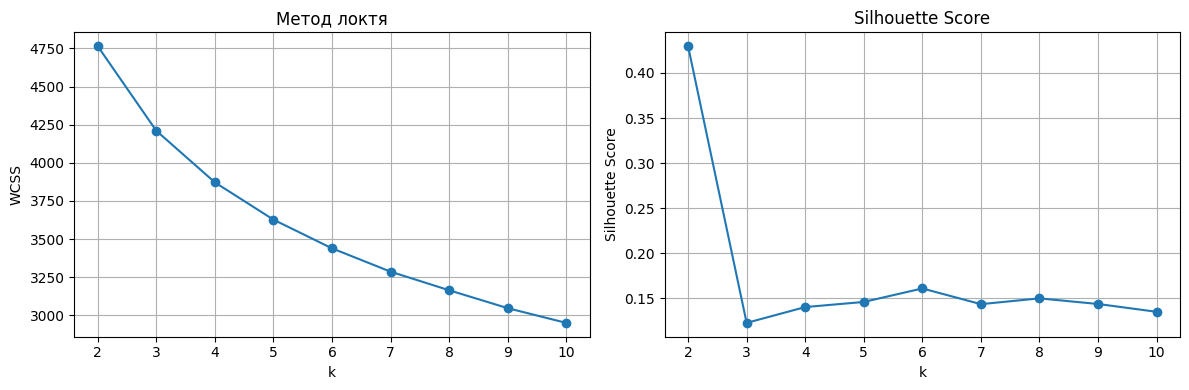

In [87]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

X_kmeans = doc_vectors_pca

wcss = []
sil_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_kmeans)

    wcss.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X_kmeans, labels))

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(k_range, wcss, marker='o')
plt.xlabel("k")
plt.ylabel("WCSS")
plt.title("Метод локтя")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(k_range, sil_scores, marker='o')
plt.xlabel("k")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score")
plt.grid(True)

plt.tight_layout()
plt.show()


Несмотря на максимальное значение Silhouette при k=2, данный вариант слишком грубый для тематической кластеризации новостей.Наблюдается локальный максимум Silhouette при k = 6, поэтому в качестве компромиссного решения между качеством кластеризации и интерпретируемостью результатов выбираем k=6.

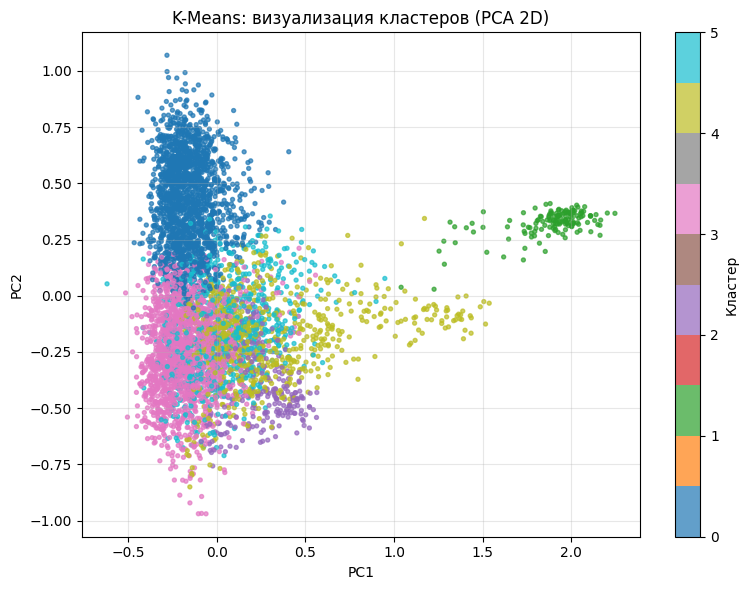

,count
cluster,
0,1779
3,1692
4,787
5,754
2,260
1,143


In [99]:
pca_vis = PCA(n_components=2, random_state=42)
X_vis = pca_vis.fit_transform(doc_vectors_pca)

k = 6

kmeans = KMeans(
    n_clusters=k,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans.fit_predict(doc_vectors_pca)
df["cluster"] = cluster_labels

plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    X_vis[:, 0],
    X_vis[:, 1],
    c=df["cluster"],
    s=8,
    cmap="tab10",
    alpha=0.7
)

plt.colorbar(scatter, label="Кластер")
plt.title("K-Means: визуализация кластеров (PCA 2D)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

df.head()
df["cluster"].value_counts()


In [100]:
# Смотрим несколько документов из 1 кластера, чтобы увидеть, объединяет ли их общая тема
cluster_id = 1

sample = df[df["cluster"] == cluster_id][["title", "description"]].head(5)

for i, row in enumerate(sample.itertuples(), 1):
    print(f"{i}. {row.title}")


1. На севере Якутии ожидается ветер скоростью более 118 км/ч
2. Осень издали помахала ручкой. О погоде в Якутии
3. Погода приготовила для якутян снежно-морозное ассорти
4. Завтра в Якутии будет греметь гроза и дуть сильный ветер
5. Лето пока не желает уступать место осени. О погоде в Якутии


In [101]:
# Наиболее частотные слова внутри кластера
from collections import Counter

indices = df[df["cluster"] == cluster_id].index.tolist()

words = []
for idx in indices:
    words.extend(tokenized_texts[idx])

Counter(words).most_common(10)


[('место', 663),
 ('запад', 586),
 ('ветер', 521),
 ('ожидаться', 505),
 ('северо', 498),
 ('район', 481),
 ('восток', 420),
 ('скорость', 415),
 ('температура', 397),
 ('воздух', 393)]

## Предсказать кластеры методом DecisionTree

Обучение Decision Tree с GridSearchCV...
Лучшие параметры: {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2}
Лучший CV accuracy: 0.841683829940768

Результаты на тестовой выборке:
Test accuracy: 0.816

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.84      0.86       534
           1       1.00      0.98      0.99        43
           2       0.89      0.87      0.88        78
           3       0.79      0.83      0.81       508
           4       0.76      0.76      0.76       236
           5       0.74      0.73      0.73       226

    accuracy                           0.82      1625
   macro avg       0.84      0.83      0.84      1625
weighted avg       0.82      0.82      0.82      1625



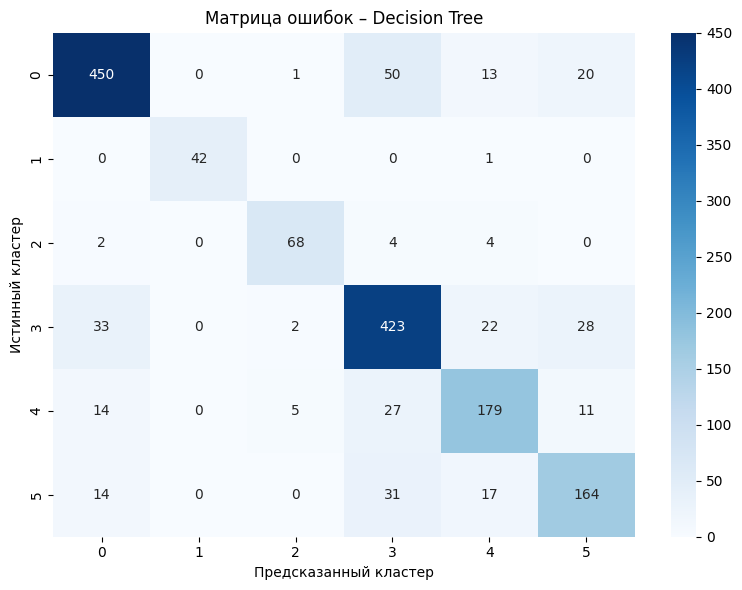

In [102]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Признаки
X = doc_vectors # документные векторы
y = df["cluster"]  # номера кластеров

# Деление на train и test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# Модель Decision Tree (создаем пустое дерево)
dt = DecisionTreeClassifier(random_state=42)

# Гиперпараметры
param_grid = {
    "max_depth": [None, 5, 10, 20],  # Насколько глубоко дереву можно задавать вопросы подряд
    "min_samples_split": [2, 5, 10],  # Сколько документов должно быть в узле,чтобы дерево имело право задать новый вопрос
    "min_samples_leaf": [1, 2, 5],   # Минимальное количество документов в конечном листе
    "criterion": ["gini", "entropy"], # Как дерево измеряет, насколько хороший вопрос
}

# GridSearchCV
grid_dt = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    scoring="accuracy",
    cv=3,
    n_jobs=-1,
)

print("Обучение Decision Tree с GridSearchCV...")
grid_dt.fit(X_train, y_train)

# Лучшие параметры
print("Лучшие параметры:", grid_dt.best_params_)
print("Лучший CV accuracy:", grid_dt.best_score_)

# Оценка на тестовой выборке
best_dt = grid_dt.best_estimator_
y_pred_dt = best_dt.predict(X_test)

print("\nРезультаты на тестовой выборке:")
print("Test accuracy:", accuracy_score(y_test, y_pred_dt))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

# Матрица ошибок
cm = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.title("Матрица ошибок – Decision Tree")
plt.xlabel("Предсказанный кластер")
plt.ylabel("Истинный кластер")
plt.tight_layout()
plt.show()


## Предсказать кластеры методом KNN

Обучение KNN с GridSearchCV...
Лучшие параметры: {'metric': 'cosine', 'n_neighbors': 15, 'weights': 'distance'}
Лучший CV accuracy: 0.9385224884826497

Результаты на тестовой выборке:
Test accuracy: 0.944

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.96      0.96       534
           1       0.91      1.00      0.96        43
           2       0.96      1.00      0.98        78
           3       0.92      0.96      0.94       508
           4       0.96      0.87      0.92       236
           5       0.97      0.91      0.94       226

    accuracy                           0.94      1625
   macro avg       0.95      0.95      0.95      1625
weighted avg       0.94      0.94      0.94      1625



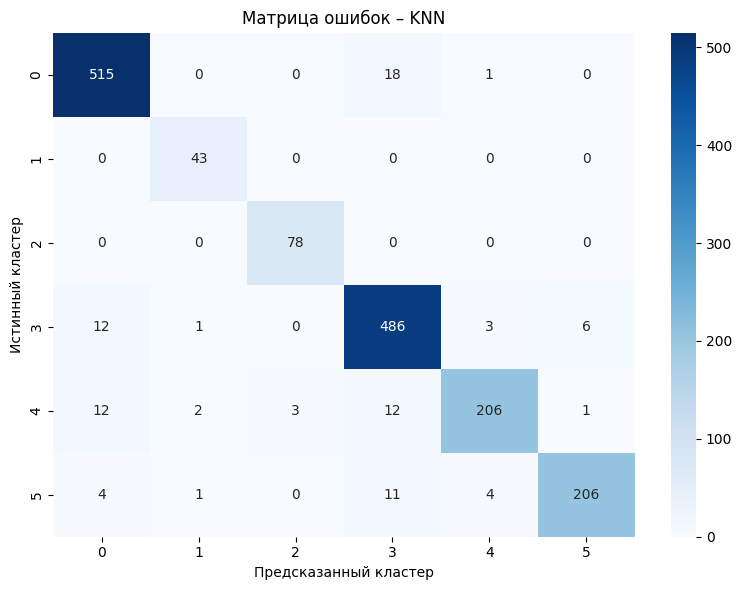

In [103]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


X = doc_vectors
y = df["cluster"]


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# Модель KNN
knn = KNeighborsClassifier()

# Uиперпараметры
param_grid = {
    "n_neighbors": [3, 5, 10, 15],  #Число соседей
    "weights": ["uniform", "distance"],  # Схема взвешивания голосов
    "metric": ["cosine"],    # Метрика расстояния
}

# GridSearchCV
grid_knn = GridSearchCV(
    estimator=knn,
    param_grid=param_grid,
    scoring="accuracy",
    cv=3,
    n_jobs=-1,
)

print("Обучение KNN с GridSearchCV...")
grid_knn.fit(X_train, y_train)

# Лучшие параметры
print("Лучшие параметры:", grid_knn.best_params_)
print("Лучший CV accuracy:", grid_knn.best_score_)

# Оценка на тестовой выборке
best_knn = grid_knn.best_estimator_
y_pred_knn = best_knn.predict(X_test)

print("\nРезультаты на тестовой выборке:")
print("Test accuracy:", accuracy_score(y_test, y_pred_knn))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn))

# Матрица ошибок
cm_knn = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_knn,
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.title("Матрица ошибок – KNN")
plt.xlabel("Предсказанный кластер")
plt.ylabel("Истинный кластер")
plt.tight_layout()
plt.show()


In [104]:
# Сравнение моделей DecisionTree и KNN

print("СРАВНЕНИЕ МОДЕЛЕЙ")

print("\nDecision Tree:")
print(f"  Лучшие параметры: {grid_dt.best_params_}")
print(f"  CV Accuracy: {grid_dt.best_score_:.4f}")
print(f"  Test Accuracy: {accuracy_score(y_test, y_pred_dt):.4f}")

print("\nKNN:")
print(f"  Лучшие параметры: {grid_knn.best_params_}")
print(f"  CV Accuracy: {grid_knn.best_score_:.4f}")
print(f"  Test Accuracy: {accuracy_score(y_test, y_pred_knn):.4f}")

# Определяем модель с лучшим качеством по CV
if grid_dt.best_score_ > grid_knn.best_score_:
    best_model_name = "Decision Tree"
else:
    best_model_name = "KNN"

print(f"\nЛучшая модель по результатам кросс-валидации: {best_model_name}")


СРАВНЕНИЕ МОДЕЛЕЙ

Decision Tree:
  Лучшие параметры: {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2}
  CV Accuracy: 0.8417
  Test Accuracy: 0.8160

KNN:
  Лучшие параметры: {'metric': 'cosine', 'n_neighbors': 15, 'weights': 'distance'}
  CV Accuracy: 0.9385
  Test Accuracy: 0.9440

Лучшая модель по результатам кросс-валидации: KNN
